# Analysis — `n1m5_T60_obs5000_seed42`

Compare the **credulous** and **vigilant** listener under two speakers (informative `inf`, persuasive `persp`), across nine true thetas. The notebook is factorized into four explicit sections:

1. **Load** the four `(speaker × listener)` belief Datasets.
2. **Compute** four per-trajectory quantities (full posterior, expected θ, MAP θ distribution, JS divergence).
3. **Aggregate** scalar summaries for line plots (central tendency + 95% interval).
4. **Visualize** with six figures:
    - **4.1** Mean posterior heatmap — one figure per speaker.
    - **4.2** Expected θ — *mean* across trajectories with 95% CI (line plot).
    - **4.3** Expected θ — *median* across trajectories with 95% CI (line plot).
    - **4.4** MAP θ distribution heatmap — one figure per speaker.
    - **4.5** JS divergence line plot — median + 95% CI.
    - **4.6** JS distribution heatmap — one figure per speaker.

Round 0 in every plot is the synthetic uniform prior, prepended to the recorded rounds 0..T-1.

## 0. Setup

In [70]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

# Bootstrap repo root onto sys.path so absolute imports work from a notebook.
HERE = Path.cwd().resolve()
# analyze.ipynb -> n1m5.../ -> simulation_experiments/ -> model/ -> repo root
REPO_ROOT = HERE.parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from model.simulation_experiments.n1m5_T60_obs5000_seed42.io import load_beliefs

DATA_ROOT = HERE / 'raw_do_not_track'
print('DATA_ROOT =', DATA_ROOT)
assert DATA_ROOT.is_dir(), f'expected experiment data at {DATA_ROOT}'

DATA_ROOT = /Users/kangke/projects/prag_net/models/simulations/simulation_experiments/n1m5_T60_obs5000_seed42/raw_do_not_track


In [71]:
# Identifiers — must match the directory names produced by run.py.
SPEAKERS = {
    'inf':   'inf_L1strat_a3_b1_uiF',
    'persp': 'persp_L1strat_a3_b0_uiF',
}
LISTENERS = {
    'credulous': 'credulous_L1coop_a3_uiF',
    'vigilant':  'vigilant_L1strat_a3_uiF',
}

# TRUE_THETAS is the set of true thetas at which observations were sampled
# (the figure columns). The agents' belief grid is wider — it also includes
# 0.0 and 1.0 — and shows up in the loaded data as belief_ds.theta
# (length 11). Don't confuse the two.
TRUE_THETAS = [round(0.1 * k, 1) for k in range(1, 10)]   # [0.1, ..., 0.9]

# Plot config
LISTENER_COLORS = {'credulous': 'tab:blue', 'vigilant': 'tab:orange'}
LISTENER_TITLES = {'credulous': 'Credulous listener', 'vigilant': 'Vigilant listener'}
SPEAKER_TITLES  = {'inf': 'Informative speaker', 'persp': 'Persuasive (pers+) speaker'}

## 1. Load

In [72]:
def load_belief_grid(data_root, speakers, listeners):
    '''Return a dict {(spk_key, lst_key): xr.Dataset} for every (speaker, listener) pair.'''
    out = {}
    for spk_key, spk_dir in speakers.items():
        for lst_key, lst_dir in listeners.items():
            out[(spk_key, lst_key)] = load_beliefs(data_root / spk_dir / lst_dir)
    return out

beliefs = load_belief_grid(DATA_ROOT, SPEAKERS, LISTENERS)
for k, ds in beliefs.items():
    print(f'{k}: sizes={dict(ds.sizes)} path={ds.attrs["execution_path"]}')

('inf', 'credulous'): sizes={'theta_true': 9, 'obs_idx': 5000, 'utt_idx': 1, 't': 60, 'theta': 11, 'psi': 1, 'alpha_val': 1} path=fast
('inf', 'vigilant'): sizes={'theta_true': 9, 'obs_idx': 5000, 'utt_idx': 1, 't': 60, 'theta': 11, 'psi': 3, 'alpha_val': 1} path=fast
('persp', 'credulous'): sizes={'theta_true': 9, 'obs_idx': 5000, 'utt_idx': 1, 't': 60, 'theta': 11, 'psi': 1, 'alpha_val': 1} path=fast
('persp', 'vigilant'): sizes={'theta_true': 9, 'obs_idx': 5000, 'utt_idx': 1, 't': 60, 'theta': 11, 'psi': 3, 'alpha_val': 1} path=fast


## 2. Compute

**Per-trajectory quantities** — each shape `(n_true_theta, n_traj, n_rounds)`, with round 0 = synthetic uniform prior:
- Expected θ:    $\mathbb{E}[\theta \mid u_{0..t}] = \sum_\theta \theta \cdot P(\theta \mid u_{0..t})$.
- JS divergence: $\mathrm{JS}(p_i, \bar p)$, in nats.

**Per-round summaries across trajectories** — each shape `(n_true_theta, n_rounds, n_grid)`:
- Mean posterior:   $\bar p_k(\theta)$.
- MAP distribution: tie-aware fraction of trajectories whose MAP is at each grid cell.

**JS distribution heatmap input** — bin per-trajectory JS values per round into `n_bins`, giving shape `(n_true_theta, n_rounds, n_bins)`.

`obs_idx × utt_idx` are stacked into a single trajectory axis before any of the above.

In [73]:
def belief_with_prior(belief_ds):
    '''Stack obs+utt into traj, prepend uniform prior at round 0.'''
    bt = belief_ds.belief_theta.stack(traj=('obs_idx', 'utt_idx')).transpose(
        'theta_true', 'traj', 't', 'theta'
    )
    arr = bt.values
    n_thetas, n_traj, _, n_grid = arr.shape
    prior_block = np.full((n_thetas, n_traj, 1, n_grid), 1.0 / n_grid)
    return np.concatenate([prior_block, arr], axis=2)


def expectation_per_traj(belief_arr, theta_grid):
    '''E[θ | u_{0..t}] per trajectory; shape (n_thetas, n_traj, n_rounds).'''
    return (belief_arr * theta_grid).sum(axis=-1)


def map_distribution(belief_arr):
    '''Tie-aware empirical distribution of trajectory MAPs.

    A trajectory whose posterior has k tied modes contributes 1/k to each
    tied grid cell. Round 0's uniform prior thus spreads to 1/|Θ| per cell
    instead of collapsing to argmax-returns-zero.

    Returns shape (n_thetas, n_rounds, n_grid).
    '''
    max_val = belief_arr.max(axis=-1, keepdims=True)
    is_max = belief_arr == max_val
    n_ties = is_max.sum(axis=-1, keepdims=True)
    weights = is_max.astype(np.float64) / n_ties
    return weights.mean(axis=1)


def _kl_safe(p, q, axis=-1):
    '''KL(p || q) summed along axis; treats 0 * log(0/_) as 0 and drops infs.'''
    with np.errstate(divide='ignore', invalid='ignore'):
        terms = p * (np.log(p) - np.log(q))
    return np.where(np.isfinite(terms), terms, 0.0).sum(axis=axis)


def js_per_trajectory(belief_arr):
    '''Per-trajectory JS(p_i, mean_p) in nats; shape (n_thetas, n_traj, n_rounds).'''
    mean_p = belief_arr.mean(axis=1, keepdims=True)
    m = 0.5 * (belief_arr + mean_p)
    return 0.5 * (_kl_safe(belief_arr, m) + _kl_safe(mean_p, m))


def histogram_per_round(values_arr, bins):
    '''Histogram along the trajectory axis at each (true_theta, round).

    values_arr: (n_thetas, n_traj, n_rounds)
    bins:       1-D array of bin edges, length n_bins+1
    Returns:    (n_thetas, n_rounds, n_bins) — fraction of trajectories per bin
    '''
    n_thetas, n_traj, n_rounds = values_arr.shape
    n_bins = len(bins) - 1
    out = np.zeros((n_thetas, n_rounds, n_bins))
    for tt in range(n_thetas):
        for r in range(n_rounds):
            counts, _ = np.histogram(values_arr[tt, :, r], bins=bins)
            out[tt, r] = counts / n_traj
    return out

In [74]:
THETA_GRID = beliefs[('inf', 'credulous')].theta.values

# Full per-trajectory posterior, with prior prepended at round 0.
full_belief = {k: belief_with_prior(ds) for k, ds in beliefs.items()}

# Cross-trajectory mean posterior (for the §4.1 heatmap).
mean_posterior = {k: arr.mean(axis=1) for k, arr in full_belief.items()}

# Per-trajectory expected θ.
e_theta_traj = {k: expectation_per_traj(arr, THETA_GRID) for k, arr in full_belief.items()}

# MAP distribution across trajectories (tie-aware).
map_dist = {k: map_distribution(arr) for k, arr in full_belief.items()}

# Per-trajectory JS divergence (nats).
js_traj = {k: js_per_trajectory(arr) for k, arr in full_belief.items()}

# Bin the per-trajectory JS into a per-round histogram (for the §4.6 heatmap).
JS_VMAX_TRAJ = max(arr.max() for arr in js_traj.values())
JS_BIN_EDGES = np.linspace(0.0, JS_VMAX_TRAJ * 1.001, 31)        # 30 bins
JS_BIN_CENTERS = 0.5 * (JS_BIN_EDGES[:-1] + JS_BIN_EDGES[1:])
js_dist = {k: histogram_per_round(arr, JS_BIN_EDGES) for k, arr in js_traj.items()}

print('Per-trajectory quantities:')
for k in beliefs:
    print(f'  {k}: e_theta {e_theta_traj[k].shape}; js {js_traj[k].shape}')
print(f'JS bins: {len(JS_BIN_CENTERS)} bins on [0, {JS_BIN_EDGES[-1]:.4f}] nats')

Per-trajectory quantities:
  ('inf', 'credulous'): e_theta (9, 5000, 61); js (9, 5000, 61)
  ('inf', 'vigilant'): e_theta (9, 5000, 61); js (9, 5000, 61)
  ('persp', 'credulous'): e_theta (9, 5000, 61); js (9, 5000, 61)
  ('persp', 'vigilant'): e_theta (9, 5000, 61); js (9, 5000, 61)
JS bins: 30 bins on [0, 0.6928] nats


## 3. Aggregate

For the line plots, summarize each per-trajectory array as central tendency + 95% interval (2.5/97.5 percentiles):

- `summaries_e_theta_mean` — *mean* of E[θ] across trajectories.
- `summaries_e_theta_med`  — *median* of E[θ] across trajectories.
- `summaries_js`           — median of per-trajectory JS across trajectories.

Each summary is a tuple `(central, lo, hi)` of shape `(n_true_theta, n_rounds)`.

In [75]:
def summarize_traj(arr, center='median', lo_pct=2.5, hi_pct=97.5):
    '''arr: (n_thetas, n_traj, n_rounds). Returns (central, lo, hi), each (n_thetas, n_rounds).'''
    if center == 'median':
        central = np.median(arr, axis=1)
    elif center == 'mean':
        central = np.mean(arr, axis=1)
    else:
        raise ValueError(f"center must be 'median' or 'mean', got {center!r}")
    lo = np.percentile(arr, lo_pct, axis=1)
    hi = np.percentile(arr, hi_pct, axis=1)
    return central, lo, hi


summaries_e_theta_mean = {k: summarize_traj(arr, center='mean')   for k, arr in e_theta_traj.items()}
summaries_e_theta_med  = {k: summarize_traj(arr, center='median') for k, arr in e_theta_traj.items()}
summaries_js           = {k: summarize_traj(arr, center='median') for k, arr in js_traj.items()}

# Quick sanity at theta_true=0.5 (idx 4)
print('Persuasive speaker, theta_true=0.5:')
for label, summ in [('mean   E[θ]', summaries_e_theta_mean),
                     ('median E[θ]', summaries_e_theta_med),
                     ('median JS  ', summaries_js)]:
    c, lo, hi = summ[('persp', 'vigilant')]
    print(f'  vigilant {label}  round 0: c={c[4, 0]:.4f}  CI=[{lo[4, 0]:.4f}, {hi[4, 0]:.4f}]')
    print(f'  vigilant {label}  round T: c={c[4, -1]:.4f}  CI=[{lo[4, -1]:.4f}, {hi[4, -1]:.4f}]')

Persuasive speaker, theta_true=0.5:
  vigilant mean   E[θ]  round 0: c=0.5000  CI=[0.5000, 0.5000]
  vigilant mean   E[θ]  round T: c=0.5222  CI=[0.4198, 0.7359]
  vigilant median E[θ]  round 0: c=0.5000  CI=[0.5000, 0.5000]
  vigilant median E[θ]  round T: c=0.5114  CI=[0.4198, 0.7359]
  vigilant median JS    round 0: c=0.0000  CI=[0.0000, 0.0000]
  vigilant median JS    round T: c=0.0689  CI=[0.0349, 0.3763]


## 4. Visualize

Two helpers used throughout:

- `plot_belief_grid` — line-plot grid (rows = speakers, cols = true θ) with listener lines + 95% CI shading.
- `plot_heatmap_grid` — heatmap grid (rows = listeners, cols = true θ); one figure per speaker.

The heatmaps use a custom diverging blue–white–red colormap (`LIGHT_BWR`) built from matplotlib's named `lightskyblue` and `lightcoral`. Where the data has a meaningful "prior" (mean posterior, MAP distribution), white is anchored at $1/|\Theta| \approx 0.091$ via `TwoSlopeNorm`. For the JS distribution heatmap (no prior), white sits at the cmap midpoint via plain `Normalize`.

In [76]:
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm


# Light diverging blue-white-red.
LIGHT_BWR = LinearSegmentedColormap.from_list(
    'light_bwr',
    [mcolors.to_rgb('lightskyblue'),
     (1.0, 1.0, 1.0),
     mcolors.to_rgb('lightcoral')],
    N=256,
)


def plot_belief_grid(summaries, true_thetas, speakers, listeners,
                     listener_colors, speaker_titles,
                     y_label, fig_title=None,
                     ylim=(0, 1), truth_line=True):
    '''Line-plot grid: rows = speakers, cols = true θ, listener lines overlaid.'''
    n_rows, n_cols = len(speakers), len(true_thetas)
    fig, axes = plt.subplots(n_rows, n_cols,
        figsize=(2.0 * n_cols, 2.5 * n_rows),
        sharex=True, sharey=True, squeeze=False)

    any_central = next(iter(summaries.values()))[0]
    n_rounds = any_central.shape[1]
    rounds = np.arange(n_rounds)

    for row, spk in enumerate(speakers):
        for col, theta_true in enumerate(true_thetas):
            ax = axes[row, col]
            if truth_line:
                ax.axhline(theta_true, color='black', linestyle='--',
                           linewidth=0.8, alpha=0.6)
            for lst in listeners:
                c, lo, hi = summaries[(spk, lst)]
                color = listener_colors[lst]
                ax.plot(rounds, c[col], color=color, label=lst, linewidth=1.6)
                ax.fill_between(rounds, lo[col], hi[col], color=color, alpha=0.18)
            if row == 0:
                ax.set_title(f'$\\theta_{{true}}={theta_true}$', fontsize=10)
            if col == 0:
                ax.set_ylabel(f'{speaker_titles[spk]}\n{y_label}', fontsize=9)
            if row == n_rows - 1:
                ax.set_xlabel('round')
            if ylim is not None:
                ax.set_ylim(*ylim)
            ax.set_xlim(0, n_rounds - 1)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if fig_title is not None:
        fig.suptitle(fig_title, fontsize=12, y=1.02)
    fig.legend(handles, labels, loc='upper center', ncol=len(labels),
               bbox_to_anchor=(0.5, 1.0), fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return fig


def plot_heatmap_grid(data_per_listener, y_values, true_thetas,
                      listeners, listener_titles,
                      vmax, value_label, speaker_label,
                      vcenter=None, cmap=LIGHT_BWR,
                      y_label='θ', truth_line=True):
    '''Heatmap grid: rows = listeners, cols = true θ. One figure per speaker.

    `data_per_listener[lst]`: (n_true_theta, n_rounds, n_y_bins)
    `y_values`:               1-D y-axis values (e.g. θ grid or JS bin centers)
    If `vcenter` is given, white anchored there via TwoSlopeNorm; else linear Normalize.
    '''
    if vcenter is not None:
        norm = TwoSlopeNorm(vcenter=vcenter, vmin=0.0,
                            vmax=max(vmax, vcenter * 1.001))
    else:
        norm = Normalize(vmin=0.0, vmax=vmax)

    n_rows, n_cols = len(listeners), len(true_thetas)
    fig, axes = plt.subplots(n_rows, n_cols,
        figsize=(2.0 * n_cols, 2.5 * n_rows),
        sharex=True, sharey=True, squeeze=False)
    n_rounds = next(iter(data_per_listener.values())).shape[1]

    # y-axis extent — bracket the bin centers by half a step
    if len(y_values) > 1:
        dy_lo = float(y_values[1] - y_values[0]) * 0.5
        dy_hi = float(y_values[-1] - y_values[-2]) * 0.5
    else:
        dy_lo = dy_hi = 0.05
    y_min = float(y_values[0])  - dy_lo
    y_max = float(y_values[-1]) + dy_hi

    im = None
    for row, lst in enumerate(listeners):
        data = data_per_listener[lst]
        for col, theta_true in enumerate(true_thetas):
            ax = axes[row, col]
            arr = data[col].T   # (n_y_bins, n_rounds)
            im = ax.imshow(arr,
                aspect='auto', origin='lower',
                extent=[-0.5, n_rounds - 0.5, y_min, y_max],
                norm=norm, cmap=cmap)
            if truth_line:
                ax.axhline(theta_true, color='black', linestyle='--',
                           linewidth=0.9, alpha=0.85)
            if row == 0:
                ax.set_title(f'$\\theta_{{true}}={theta_true}$', fontsize=10)
            if col == 0:
                ax.set_ylabel(f'{listener_titles[lst]}\n{y_label}', fontsize=9)
            if row == n_rows - 1:
                ax.set_xlabel('round')

    if im is not None:
        cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                            shrink=0.85, pad=0.02, aspect=25)
        cbar.set_label(value_label)
    fig.suptitle(speaker_label, fontsize=12, y=1.0)
    return fig

### 4.1 Mean posterior heatmap

Color = mean $P(\theta \mid u_{0..t})$ across trajectories. White anchored at the uniform prior $1/|\Theta| \approx 0.091$ via `TwoSlopeNorm`. Two figures (one per speaker), each 2 × 9 (rows = listeners, cols = true θ). Black dashed line marks the truth.

In [77]:
# Shared vmax across both speakers and both listeners.
MEAN_POST_VMAX = max(arr.max() for arr in mean_posterior.values())
print(f'MEAN_POST_VMAX = {MEAN_POST_VMAX:.3f}')

MEAN_POST_VMAX = 0.979


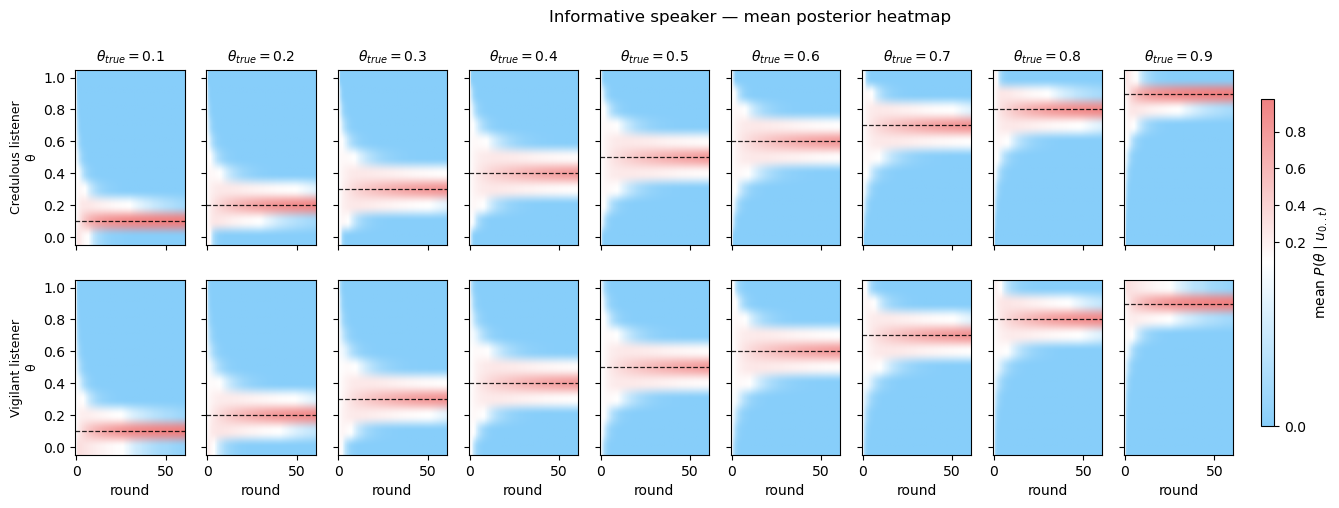

In [78]:
inf_means = {lst: mean_posterior[('inf', lst)] for lst in LISTENERS}
plot_heatmap_grid(
    inf_means, THETA_GRID, TRUE_THETAS,
    listeners=list(LISTENERS.keys()),
    listener_titles=LISTENER_TITLES,
    vmax=MEAN_POST_VMAX,
    value_label=r'mean $P(\theta \mid u_{0..t})$',
    speaker_label='Informative speaker — mean posterior heatmap',
    vcenter=1 / len(THETA_GRID),
)
plt.show()

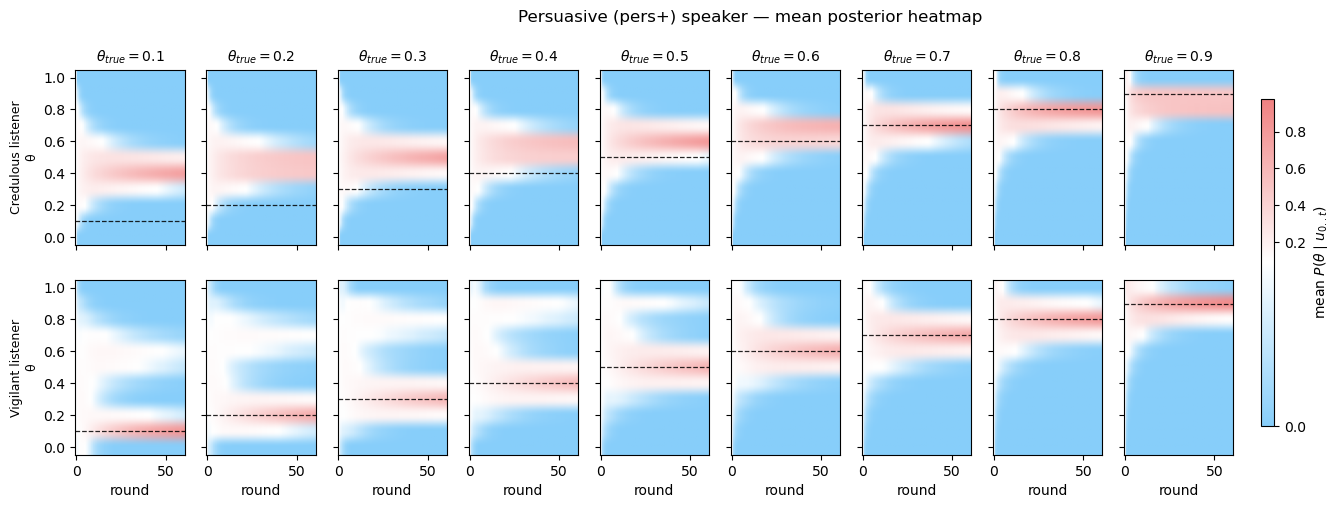

In [79]:
persp_means = {lst: mean_posterior[('persp', lst)] for lst in LISTENERS}
plot_heatmap_grid(
    persp_means, THETA_GRID, TRUE_THETAS,
    listeners=list(LISTENERS.keys()),
    listener_titles=LISTENER_TITLES,
    vmax=MEAN_POST_VMAX,
    value_label=r'mean $P(\theta \mid u_{0..t})$',
    speaker_label='Persuasive (pers+) speaker — mean posterior heatmap',
    vcenter=1 / len(THETA_GRID),
)
plt.show()

### 4.2 Expected θ — mean across trajectories

Mean of $\mathbb{E}[\theta \mid u_{0..t}]$ across trajectories with 2.5/97.5 percentile shading. Truth dashed black.

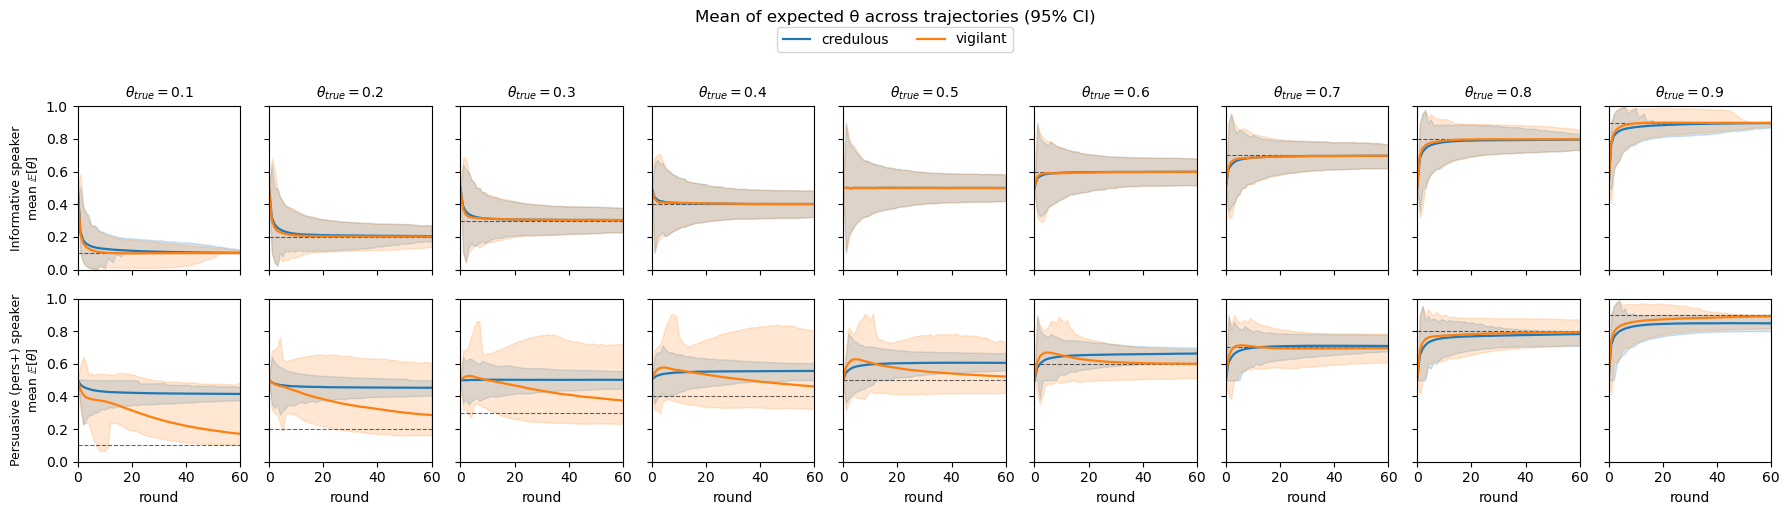

In [80]:
plot_belief_grid(
    summaries_e_theta_mean, TRUE_THETAS,
    speakers=list(SPEAKERS.keys()),
    listeners=list(LISTENERS.keys()),
    listener_colors=LISTENER_COLORS,
    speaker_titles=SPEAKER_TITLES,
    y_label=r'mean $\mathbb{E}[\theta]$',
    fig_title='Mean of expected θ across trajectories (95% CI)',
)
plt.show()

### 4.3 Expected θ — median across trajectories

Median of $\mathbb{E}[\theta \mid u_{0..t}]$ across trajectories with 2.5/97.5 percentile shading. Truth dashed black.

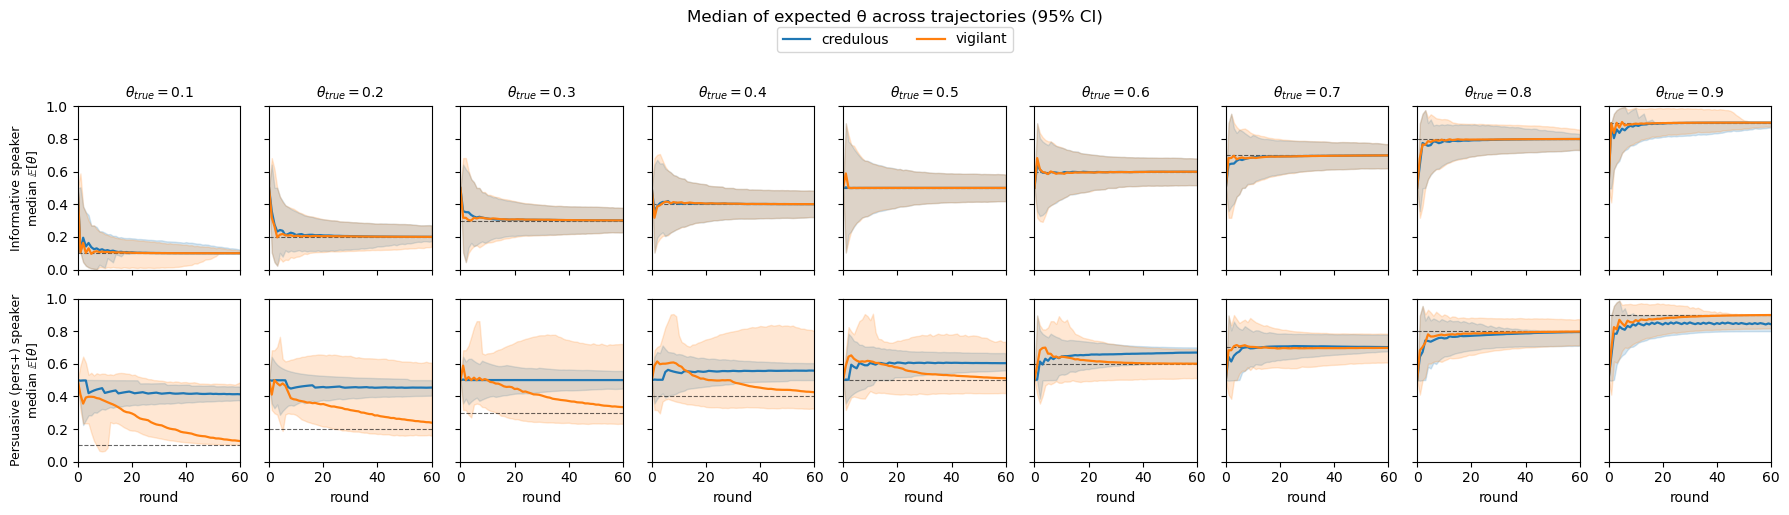

In [81]:
plot_belief_grid(
    summaries_e_theta_med, TRUE_THETAS,
    speakers=list(SPEAKERS.keys()),
    listeners=list(LISTENERS.keys()),
    listener_colors=LISTENER_COLORS,
    speaker_titles=SPEAKER_TITLES,
    y_label=r'median $\mathbb{E}[\theta]$',
    fig_title='Median of expected θ across trajectories (95% CI)',
)
plt.show()

### 4.4 MAP θ distribution heatmap

Color = fraction of trajectories whose posterior MAP is at each grid value. Tie-aware (round 0's uniform prior spreads to $1/|\Theta|$ rather than collapsing to argmax-returns-zero). Same 2 × 9 layout as §4.1, one figure per speaker.

In [82]:
MAP_VMAX = max(arr.max() for arr in map_dist.values())
print(f'MAP_VMAX = {MAP_VMAX:.3f}')

MAP_VMAX = 0.987


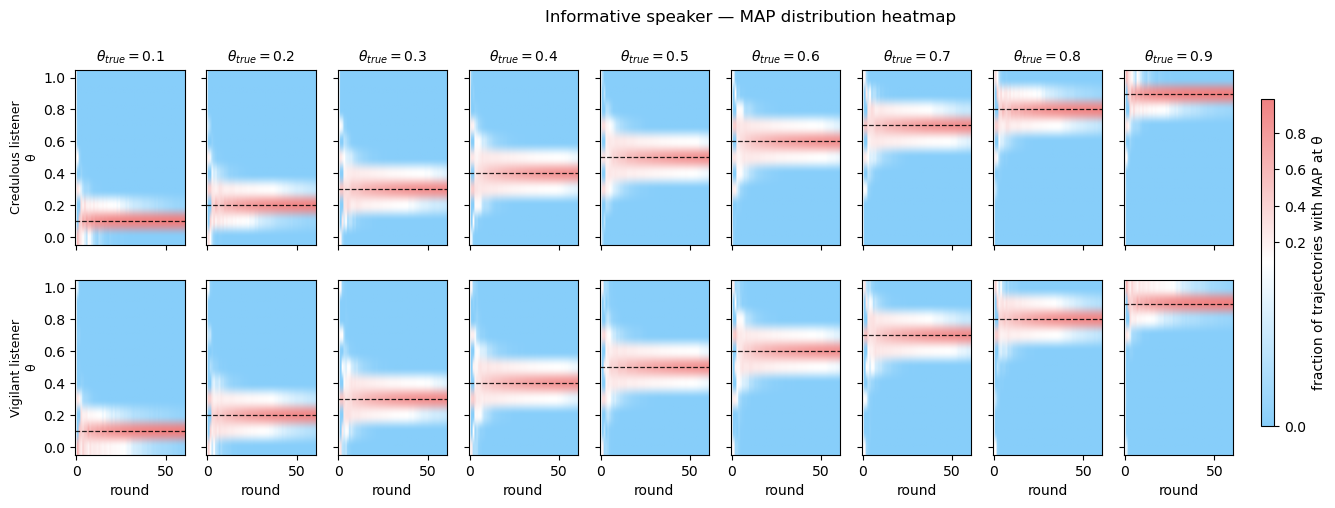

In [83]:
inf_maps = {lst: map_dist[('inf', lst)] for lst in LISTENERS}
plot_heatmap_grid(
    inf_maps, THETA_GRID, TRUE_THETAS,
    listeners=list(LISTENERS.keys()),
    listener_titles=LISTENER_TITLES,
    vmax=MAP_VMAX,
    value_label='fraction of trajectories with MAP at θ',
    speaker_label='Informative speaker — MAP distribution heatmap',
    vcenter=1 / len(THETA_GRID),
)
plt.show()

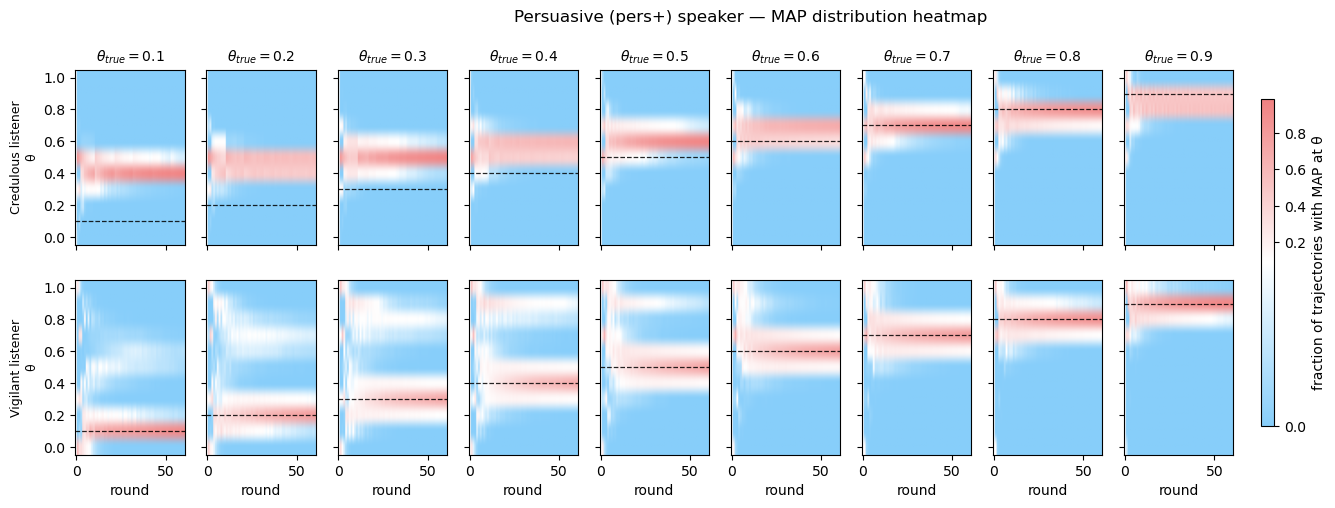

In [84]:
persp_maps = {lst: map_dist[('persp', lst)] for lst in LISTENERS}
plot_heatmap_grid(
    persp_maps, THETA_GRID, TRUE_THETAS,
    listeners=list(LISTENERS.keys()),
    listener_titles=LISTENER_TITLES,
    vmax=MAP_VMAX,
    value_label='fraction of trajectories with MAP at θ',
    speaker_label='Persuasive (pers+) speaker — MAP distribution heatmap',
    vcenter=1 / len(THETA_GRID),
)
plt.show()

### 4.5 JS divergence — line plot

Median of per-trajectory $\mathrm{JS}(p_i, \bar p)$ in nats with 2.5/97.5 percentile shading. $D_0 = 0$ at round 0 because every trajectory shares the prior.

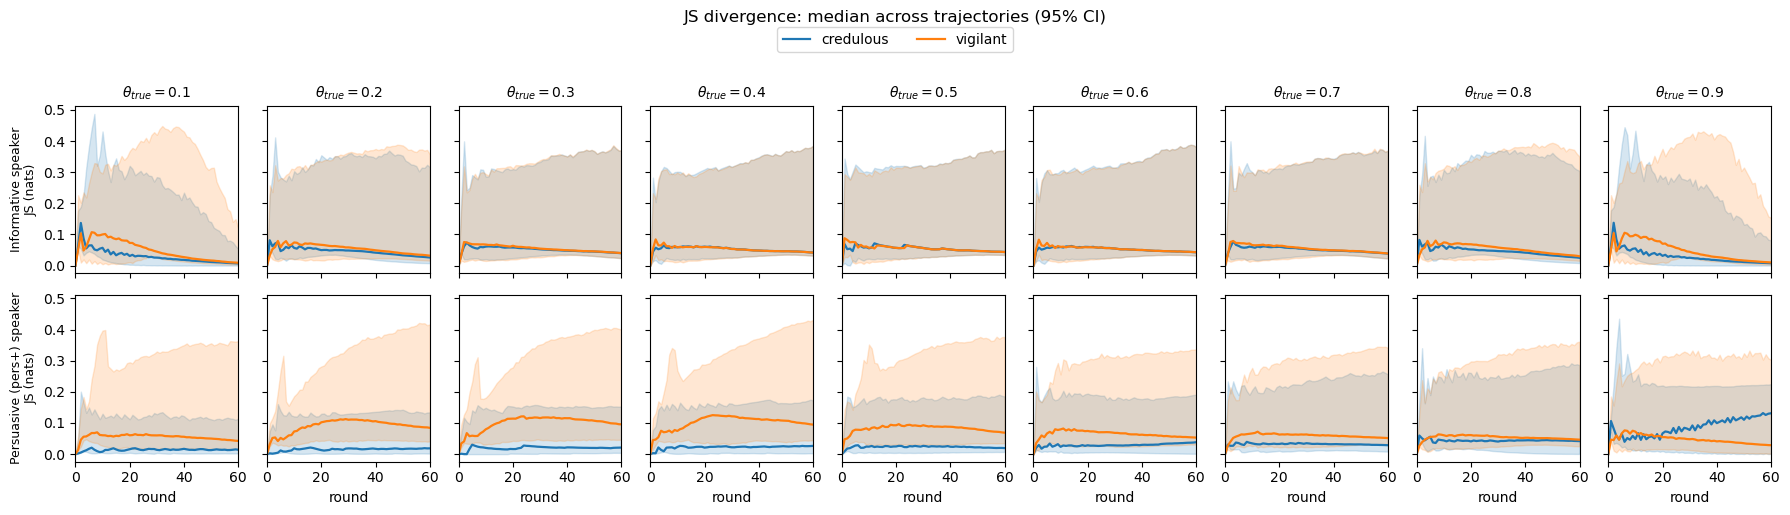

In [85]:
plot_belief_grid(
    summaries_js, TRUE_THETAS,
    speakers=list(SPEAKERS.keys()),
    listeners=list(LISTENERS.keys()),
    listener_colors=LISTENER_COLORS,
    speaker_titles=SPEAKER_TITLES,
    y_label='JS (nats)',
    fig_title='JS divergence: median across trajectories (95% CI)',
    ylim=None,           # let y-axis auto-scale
    truth_line=False,
)
plt.show()

### 4.6 JS distribution heatmap

Color = fraction of trajectories whose JS divergence at round $t$ falls in a given bin (per-round histogram of `js_traj`, 30 bins on $[0, \mathrm{JS}_{\max}]$). Same 2 × 9 layout as §4.4, one figure per speaker. No prior anchor — `Normalize(0, vmax)` with white at the cmap midpoint.

In [86]:
JS_DIST_VMAX = max(arr.max() for arr in js_dist.values())
print(f'JS_DIST_VMAX = {JS_DIST_VMAX:.3f}')

JS_DIST_VMAX = 1.000


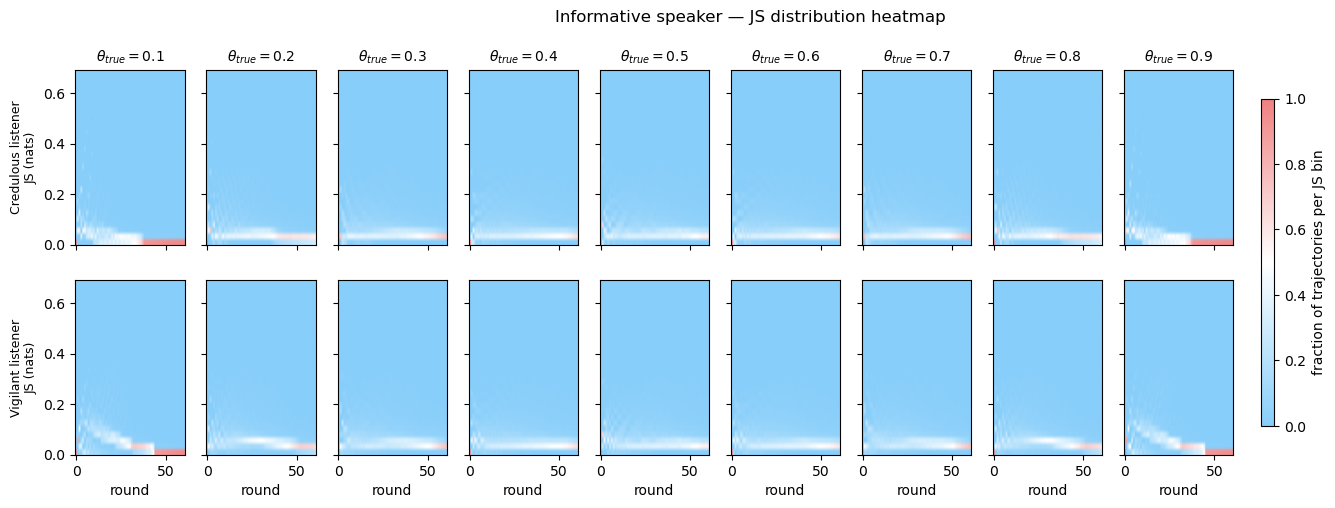

In [87]:
inf_js = {lst: js_dist[('inf', lst)] for lst in LISTENERS}
plot_heatmap_grid(
    inf_js, JS_BIN_CENTERS, TRUE_THETAS,
    listeners=list(LISTENERS.keys()),
    listener_titles=LISTENER_TITLES,
    vmax=JS_DIST_VMAX,
    value_label='fraction of trajectories per JS bin',
    speaker_label='Informative speaker — JS distribution heatmap',
    y_label='JS (nats)',
    truth_line=False,
)
plt.show()

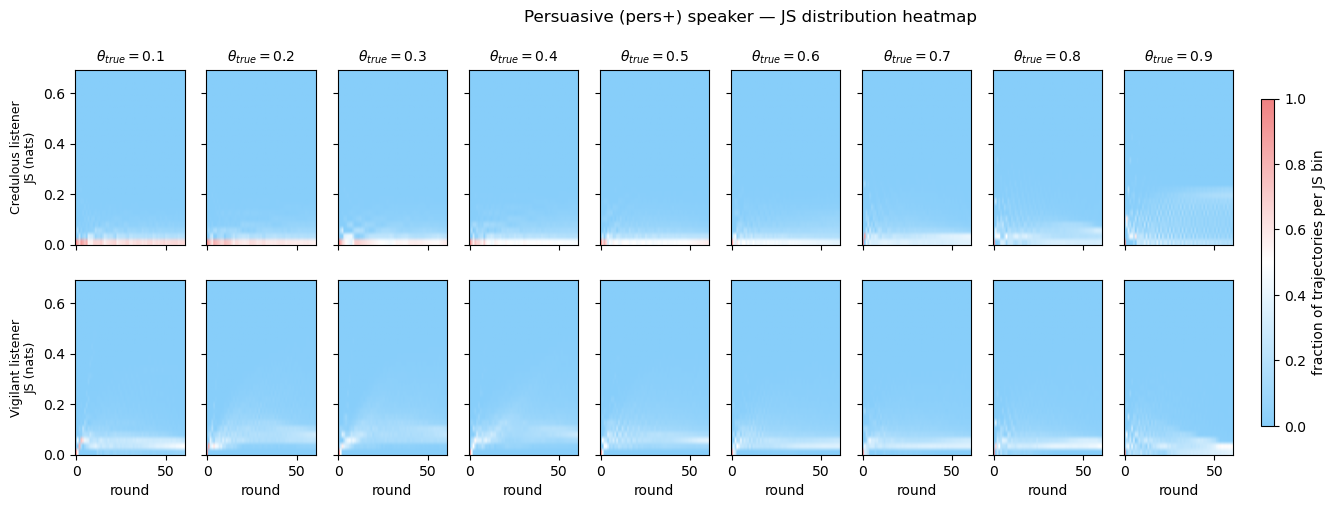

In [88]:
persp_js = {lst: js_dist[('persp', lst)] for lst in LISTENERS}
plot_heatmap_grid(
    persp_js, JS_BIN_CENTERS, TRUE_THETAS,
    listeners=list(LISTENERS.keys()),
    listener_titles=LISTENER_TITLES,
    vmax=JS_DIST_VMAX,
    value_label='fraction of trajectories per JS bin',
    speaker_label='Persuasive (pers+) speaker — JS distribution heatmap',
    y_label='JS (nats)',
    truth_line=False,
)
plt.show()

## 5. CogSci paper figures

Two figures focused on `theta_true = 0.2`, sized for a two-column conference paper (CogSci proceedings, ~6.85" full text width):

- **§5.1**: 2 × 2 mean-posterior heatmap (rows = listeners, cols = speakers).
- **§5.2**: 1 × 2 mean-of-E[θ] line plot (cols = speakers; listeners overlaid).

Both are 6.5" wide; figures use 10 pt font with 9 pt tick labels and label x at every 10 rounds.

### 5.1 Mean posterior heatmap (`theta_true = 0.2`)

**2 × 2** layout: rows = listeners (credulous on top, vigilant on bottom), cols = speakers (informative left, persuasive right). x-axis is rounds 0..60 with ticks at every 10. Same `LIGHT_BWR` colormap and prior-anchored `TwoSlopeNorm` as §4.1.

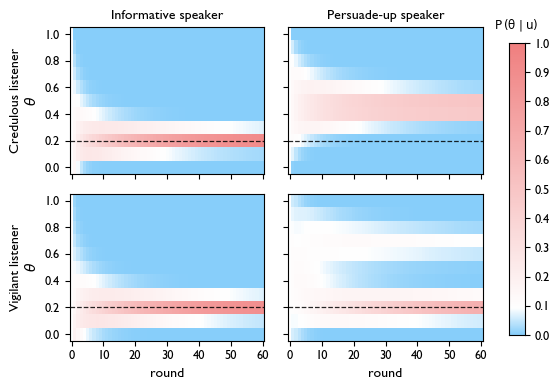

In [96]:
PAPER_THETA = 0.2
PAPER_THETA_IDX = TRUE_THETAS.index(PAPER_THETA)
PAPER_FONT = 10
PAPER_X_TICKS = [0, 10, 20, 30, 40, 50, 60]
PAPER_Y_TICKS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

PAPER_SPEAKER_TITLES = {'inf': SPEAKER_TITLES['inf'], 'persp': 'Persuade-up speaker'}

_v_p1 = 1 / len(THETA_GRID)
_norm_p1 = TwoSlopeNorm(vcenter=_v_p1, vmin=0, vmax=1.0)

with plt.rc_context({'font.family': 'Gill Sans'}):
    fig_p1, axes_p1 = plt.subplots(2, 2,
                                    figsize=(6.5, 4.0),
                                    sharex=True, sharey=True)

    n_rounds_p1 = mean_posterior[('inf', 'credulous')].shape[1]
    _dy = float(THETA_GRID[1] - THETA_GRID[0]) * 0.5
    _y_min = float(THETA_GRID[0]) - _dy
    _y_max = float(THETA_GRID[-1]) + _dy

    for r_idx, lst in enumerate(['credulous', 'vigilant']):
        for c_idx, spk in enumerate(['inf', 'persp']):
            ax = axes_p1[r_idx, c_idx]
            data = mean_posterior[(spk, lst)][PAPER_THETA_IDX]   # (n_rounds, n_grid)
            ax.imshow(
                data.T,                          # (n_grid, n_rounds)
                aspect='auto', origin='lower',
                extent=[-0.5, n_rounds_p1 - 0.5, _y_min, _y_max],
                norm=_norm_p1, cmap=LIGHT_BWR,
            )
            ax.axhline(PAPER_THETA, color='black', linestyle='--',
                       linewidth=0.9, alpha=0.85)
            if r_idx == 0:
                ax.set_title(PAPER_SPEAKER_TITLES[spk], fontsize=PAPER_FONT)
            if c_idx == 0:
                ax.set_ylabel(f'{LISTENER_TITLES[lst]}\n$\\theta$', fontsize=PAPER_FONT)
            if r_idx == 1:
                ax.set_xlabel('round', fontsize=PAPER_FONT)
            ax.set_xticks(PAPER_X_TICKS)
            ax.set_yticks(PAPER_Y_TICKS)
            ax.tick_params(axis='both', labelsize=PAPER_FONT - 1)

    plt.tight_layout(rect=(0, 0, 0.78, 1.0))

    # Custom colorbar: 256 data values 0→1, each colored as TwoSlopeNorm would in the heatmap.
    _cb_vals = np.linspace(0.0, 1.0, 256)
    _cb_colors = LIGHT_BWR(_norm_p1(_cb_vals))          # (256, 4) RGBA
    _cb_img = _cb_colors.reshape(256, 1, 4)             # displayed bottom=0, top=1

    cbar_ax = fig_p1.add_axes([0.79, 0.15, 0.025, 0.73])
    cbar_ax.imshow(_cb_img, aspect='auto', extent=[0, 1, 0, 1], origin='lower')
    cbar_ax.set_xlim(0, 1)
    cbar_ax.set_ylim(0, 1)
    cbar_ax.set_xticks([])

    _cbar_ticks = np.linspace(0.0, 1.0, 11)
    cbar_ax.set_yticks(_cbar_ticks)
    cbar_ax.set_yticklabels([f'{t:.1f}' for t in _cbar_ticks])
    cbar_ax.yaxis.tick_right()
    cbar_ax.tick_params(axis='y', labelsize=PAPER_FONT - 1)

    # Label above the colorbar, horizontal, un-italicized, smaller.
    cbar_ax.text(0.5, 1.03, r'$\mathrm{P}\,(\mathrm{\theta} \mid \mathrm{u})$',
                 fontsize=PAPER_FONT - 1.5, transform=cbar_ax.transAxes,
                 ha='center', va='bottom', rotation=0)

    plt.show()

for ext in ('svg', 'pdf'):
    fig_p1.savefig(FIG_DIR / f'fig_posterior_heatmap.{ext}', bbox_inches='tight')

### 5.2 Mean of E[θ] — line plot (`theta_true = 0.2`)

Two side-by-side subplots: left = informative speaker, right = persuasive (pers+) speaker. Both listeners overlaid (credulous = blue, vigilant = orange) with 95% CI shading. Black dashed line marks the truth at θ = 0.2.

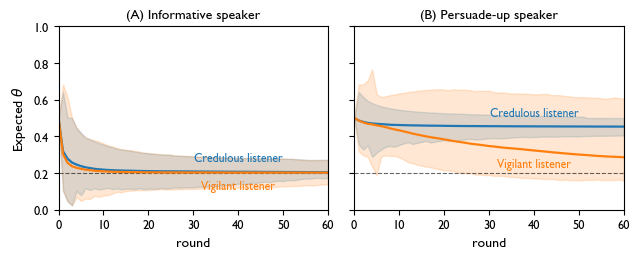

In [94]:
PAPER_PANEL_TITLES = {'inf': '(A) Informative speaker', 'persp': '(B) Persuade-up speaker'}
LISTENER_LABELS = {'credulous': 'Credulous listener', 'vigilant': 'Vigilant listener'}

with plt.rc_context({'font.family': 'Gill Sans'}):
    fig_p2, axes_p2 = plt.subplots(1, 2,
                                     figsize=(6.5, 2.7),
                                     sharey=True)

    n_rounds_p2 = next(iter(summaries_e_theta_mean.values()))[0].shape[1]
    rounds_p2 = np.arange(n_rounds_p2)

    for c_idx, spk in enumerate(['inf', 'persp']):
        ax = axes_p2[c_idx]
        ax.axhline(PAPER_THETA, color='black', linestyle='--',
                   linewidth=0.8, alpha=0.6)
        for lst in ['credulous', 'vigilant']:
            c_, lo_, hi_ = summaries_e_theta_mean[(spk, lst)]
            color = LISTENER_COLORS[lst]
            ax.plot(rounds_p2, c_[PAPER_THETA_IDX], color=color, linewidth=1.6)
            ax.fill_between(rounds_p2, lo_[PAPER_THETA_IDX], hi_[PAPER_THETA_IDX],
                            color=color, alpha=0.18)

        # Inline text labels placed at round 40, offset so they don't overlap.
        x_label = 40
        for lst in ['credulous', 'vigilant']:
            c_, _, _ = summaries_e_theta_mean[(spk, lst)]
            color = LISTENER_COLORS[lst]
            y_line = float(c_[PAPER_THETA_IDX, x_label])
            nudge = +0.04 if lst == 'credulous' else -0.04
            ax.text(x_label, y_line + nudge, LISTENER_LABELS[lst],
                    color=color, fontsize=PAPER_FONT - 1.5,
                    ha='center', va='bottom' if lst == 'credulous' else 'top')

        ax.set_title(PAPER_PANEL_TITLES[spk], fontsize=PAPER_FONT)
        ax.set_xlabel('round', fontsize=PAPER_FONT)
        if c_idx == 0:
            ax.set_ylabel(r'Expected $\theta$', fontsize=PAPER_FONT)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, n_rounds_p2 - 1)
        ax.set_xticks(PAPER_X_TICKS)
        ax.set_yticks(PAPER_Y_TICKS)
        ax.tick_params(axis='both', labelsize=PAPER_FONT - 1)

    plt.tight_layout()
    plt.show()

FIG_DIR = HERE / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
for ext in ('svg', 'pdf'):
    fig_p2.savefig(FIG_DIR / f'fig_expected_theta.{ext}', bbox_inches='tight')

### 5.3 Speaker utterance preferences (`obs = 1/5`)

Two horizontal-bar panels showing $P(u \mid \mathrm{obs})$ for an informative speaker (left) and a persuade-up speaker (right) at the observation **1 success out of 5 trials**. Speakers are level-1, strat, alpha = 3.0; informative uses beta = 1.0 and persuade-up uses beta = 0.0. World is n=1, m=5 with the default 11-point θ grid.

Utterances are ordered top-to-bottom from most-negative-toned (`all, ineffective`) to most-positive-toned (`all, effective`). The contrast is striking: at the same observation, the informative speaker overwhelmingly says `most, ineffective` while the persuade-up speaker re-frames the same data as `some, effective`.

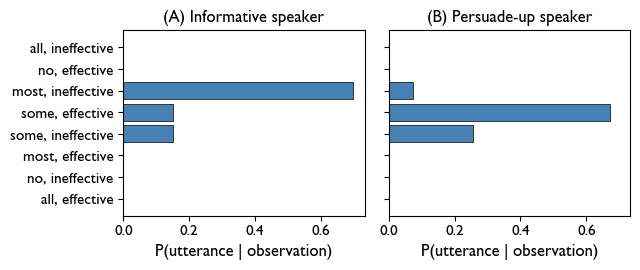

In [ ]:
from model.rsa_core import World, create_speaker

# Fresh world matching the experiment (n=1, m=5, default 11-point θ grid).
_paper_world = World(n=1, m=5)

PAPER_OBS = (0, 1, 0, 0, 0, 0)        # 1 success out of 5 trials
PAPER_OBS_LABEL = '1/5'

_inf_speaker = create_speaker(
    _paper_world, level=1, omega='strat',
    psi='inf', update_internal=False, alpha=3.0, beta=1.0,
)
_persp_speaker = create_speaker(
    _paper_world, level=1, omega='strat',
    psi='pers+', update_internal=False, alpha=3.0, beta=0.0,
)

# Display order: most-negative-toned at top → most-positive-toned at bottom.
PAPER_UTT_ORDER = [
    'all,unsuccessful',
    'no,successful',
    'most,unsuccessful',
    'some,successful',
    'some,unsuccessful',
    'most,successful',
    'no,unsuccessful',
    'all,successful',
]
PAPER_UTT_LABELS = {
    'all,unsuccessful':  'all, ineffective',
    'no,successful':     'no, effective',
    'most,unsuccessful': 'most, ineffective',
    'some,successful':   'some, effective',
    'some,unsuccessful': 'some, ineffective',
    'most,successful':   'most, effective',
    'no,unsuccessful':   'no, ineffective',
    'all,successful':    'all, effective',
}

inf_p_at_obs = np.exp(np.array(
    [_inf_speaker.utterance_log_prob_obs[PAPER_OBS][u] for u in PAPER_UTT_ORDER]
))
persp_p_at_obs = np.exp(np.array(
    [_persp_speaker.utterance_log_prob_obs[PAPER_OBS][u] for u in PAPER_UTT_ORDER]
))

display_labels = [PAPER_UTT_LABELS[u] for u in PAPER_UTT_ORDER]

_p3_font = PAPER_FONT + 2

with plt.rc_context({'font.family': 'Gill Sans'}):
    fig_p3, axes_p3 = plt.subplots(1, 2,
                                    figsize=(6.5, 2.8),
                                    sharex=True, sharey=True)

    y_pos = np.arange(len(PAPER_UTT_ORDER))
    bar_color = mcolors.to_rgb('steelblue')
    x_max = max(inf_p_at_obs.max(), persp_p_at_obs.max()) * 1.05

    for c_idx, (spk_key, p_arr) in enumerate(
            zip(['inf', 'persp'], [inf_p_at_obs, persp_p_at_obs])):
        ax = axes_p3[c_idx]
        ax.barh(y_pos, p_arr, color=bar_color,
                edgecolor='black', linewidth=0.5)
        ax.set_yticks(y_pos)
        if c_idx == 0:
            ax.set_yticklabels(display_labels, fontsize=_p3_font - 1)
        ax.set_title(PAPER_PANEL_TITLES[spk_key], fontsize=_p3_font)
        ax.set_xlabel('P(utterance | observation)', fontsize=_p3_font)
        ax.set_xlim(0, x_max)
        ax.tick_params(axis='x', labelsize=_p3_font - 1)

    # First-listed utterance at top (sharey -> invert once is enough).
    axes_p3[0].invert_yaxis()
    plt.tight_layout()
    plt.show()


for ext in ('svg', 'pdf'):
    fig_p3.savefig(FIG_DIR / f'fig_utterance_probs.{ext}', bbox_inches='tight')